# Proceso completo de limpieza, procesamiento y comparación de modelos

## Funciones de muestreo

In [1]:
def corr_matrix(df):
    plt.figure(figsize=(8, 6))

    # Excluimos la columna de fecha para la correlación numérica directa
    if 'Date' in df.columns:
        df_num = df.drop(columns=['Date'])
    else:
        df_num = df.copy()

    corr_matrix = df_num.corr()

    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Matriz de Correlación')
    plt.show()

## 1. Carga de librerías y datos

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, VotingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ocultar warnings de TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Configuraciones de visualización
sns.set_theme(style="whitegrid")

Importing plotly failed. Interactive plots will not work.


In [3]:
# load_data(), split_train_val_test()
def load_data(path: str ='../data/raw/', filename: str = 'db_orig'):
    return pd.read_csv(path + filename + '.csv')

import os
from sklearn.model_selection import train_test_split

def train_val_test_split(df, dataset_name, test_size=0.3, val_size=0.5, verbose=False):
    """
    Divide un DataFrame en train, validation y test guardándolos con un prefijo identificativo.
    
    Args:
        df: DataFrame original.
        dataset_name: Nombre o referencia (ej. 'db_orig', 'db_trunc_779') para los archivos.
        test_size: Proporción para el conjunto de test+val.
        val_size: Proporción del conjunto temporal para validación.
        verbose: Si es True, imprime información del tamaño de los conjuntos.
    """
    # Dividir datos (Primero separamos train del resto): Al ser datos temporales, ordenamos por fecha y evitamos mezclar aleatoriamente (shuffle=False)
    train_df, temp_df = train_test_split(df, test_size=test_size, shuffle=False)
    # Del resto, separamos val y test
    val_df, test_df = train_test_split(temp_df, test_size=val_size, shuffle=False)

    # Mostrar info
    if verbose:
        print(f"--- Info Dataset '{dataset_name}' ---")
        print(f"Total datos: {len(df)}")
        print(f"Train:      {len(train_df)}")
        print(f"Validation: {len(val_df)}")
        print(f"Test:       {len(test_df)}\n")

    # Ruta de guardado
    output_dir = '../data/processed'
    os.makedirs(output_dir, exist_ok=True)

    # Guardamos los conjuntos con la referencia en el nombre
    train_df.to_csv(f'{output_dir}/{dataset_name}_train.csv', index=False)
    val_df.to_csv(f'{output_dir}/{dataset_name}_val.csv', index=False)
    test_df.to_csv(f'{output_dir}/{dataset_name}_test.csv', index=False)
    
    if verbose: print(f"Archivos guardados como: {dataset_name}_[train/val/test].csv\n")
    
    return train_df, val_df, test_df


In [4]:
# Carga de datos
# db_orig = load_data(filename='db_orig')
db_trunc = load_data(filename='db_orig')

## 1. Preprocesamiento de datos

Los datos provienen de distintas fuentes y requieren diferentes funciones de limpieza:

- **Bases de datos procesadas con `preprocess_orig`**
- `db_orig.csv`  
- `db_amp.csv`

- **Bases de datos procesadas con `preprocess_trunc`**
- `db_trunc_779.csv`  
- `db_trunc_4779.csv`  
- `db_trunc_8779.csv`

In [5]:
# preprocess(), expand_features()
def preprocess(df):
    # Convertimos 'Date' a datetime
    # df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
    
    # 'Amount' viene como string con coma, € y punto. Lo pasamos a float
    if df['Amount'].dtype == 'str':
        df['Amount'] = df['Amount'].str.replace('€', '')
        df['Amount'] = df['Amount'].str.replace('.', '')
        df['Amount'] = df['Amount'].str.replace(',', '.').astype(float)

    # Convertir los gastos ('Expenses') en valores negativos
    if 'Type' in df.columns:
        df.loc[df['Type'] == 'Expenses', 'Amount'] = -df.loc[df['Type'] == 'Expenses', 'Amount'].abs()

    # Convertir las etiquetas de Area a valores numéricos
    # label_encoder = LabelEncoder()
    # df['Area'] = label_encoder.fit_transform(df['Area'])
    # print(f"Categorías: {dict(enumerate(label_encoder.classes_))}\n")

    return df

def expand_features(df):
    # Convertimos 'Date' a datetime y dividimos en meses
    # df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
    df = df.sort_values(by='Date').reset_index(drop=True)
    df['Month_End'] = df['Date'].dt.to_period('M').dt.to_timestamp('M')

    # Agrupación por categoría: nos dirá cuánto se gastó en Comida, Ocio, Facturas, etc., el mes anterior.
    area_monthly = df[df['Type'] == 'Expenses'].groupby(['Month_End', 'Area'])['Amount'].sum().unstack(fill_value=0)

    # Agrupación General (Income y Expenses)
    monthly = df.groupby(['Month_End', 'Type'])['Amount'].sum().unstack(fill_value=0).reset_index()
    if 'Expenses' not in monthly.columns: monthly['Expenses'] = 0
    if 'Income' not in monthly.columns: monthly['Income'] = 0

    # Fusionar con las Áreas de Gasto
    ts_df = monthly.set_index('Month_End').join(area_monthly, how='left').fillna(0).sort_index()
    ts_df.index.freq = 'ME'

    # Variables Temporales
    df_features = ts_df.copy()
    df_features['Month'] = df_features.index.month
    df_features['Quarter'] = df_features.index.quarter
    df_features['Is_Summer'] = df_features['Month'].isin([6, 7, 8, 9]).astype(int)

    # Lags y Variables Rodantes Aumentadas: Lags directos de 1 a 3 meses y estacional de 12 meses (donde haya datos)
    for lag in [1, 2, 3, 12]:
        df_features[f'Expenses_Lag_{lag}'] = df_features['Expenses'].shift(lag)
        df_features[f'Income_Lag_{lag}'] = df_features['Income'].shift(lag)

    # Medias Móviles y Volatilidad (Desviación Estándar)
    df_features['Expenses_Rolling_3_Mean'] = df_features['Expenses'].shift(1).rolling(window=3).mean()
    df_features['Expenses_Rolling_3_Std'] = df_features['Expenses'].shift(1).rolling(window=3).std()
    df_features['Expenses_Rolling_6_Mean'] = df_features['Expenses'].shift(1).rolling(window=6).mean()

    # Medias Móviles Exponenciales (EMA) (Da más peso a los meses recientes)
    df_features['Expenses_EMA_3'] = df_features['Expenses'].shift(1).ewm(span=3, adjust=False).mean()

    # Mover las categorías de área un paso atrás (Queremos predecir este mes usando el área del mes pasado)
    for area_col in area_monthly.columns:
        df_features[f'{area_col}_Lag_1'] = df_features[area_col].shift(1)

    df_features = df_features.drop(columns=area_monthly.columns) # Quitar el presente para no hacer trampa

    # Limpieza final
    df_features = df_features.bfill() # Llenar los primeros meses sin histórico con los valores más cercanos
    df_features['Expenses_Rolling_3_Std'] = df_features['Expenses_Rolling_3_Std'].fillna(0)

    return df_features


In [ ]:
# View
# print(f'DATABASE ORIGINAL\n{db_orig.head()}\n')
# print(f'DATABASE ORIG PREPROCESADA\n{preprocess(db_orig).head()}\n')
# print(f'DATABASE TRUNC PREPROCESADA\n{preprocess(db_trunc).head()}\n')
# expand_features(preprocess(db_trunc))



In [6]:
# Save train, val, test
# db_proc_orig = expand_features(preprocess(db_orig))
db_proc_trunc = expand_features(preprocess(db_trunc))

# train_val_test_split(db_proc_orig, dataset_name='orig', verbose=False)
train_val_test_split(db_proc_trunc, dataset_name='', verbose=False)

(            Expenses   Income  Month  Quarter  Is_Summer  Expenses_Lag_1  \
 Month_End                                                                  
 2021-09-30   -151.22  1250.62      9        3          1         -151.22   
 2021-10-31   -328.70   115.00     10        4          0         -151.22   
 2021-11-30   -258.91   270.07     11        4          0         -328.70   
 2021-12-31   -201.43   487.50     12        4          0         -258.91   
 2022-01-31    -79.02   203.99      1        1          0         -201.43   
 2022-02-28   -214.39   285.34      2        1          0          -79.02   
 2022-03-31   -439.85   659.10      3        1          0         -214.39   
 2022-04-30   -348.82     0.00      4        2          0         -439.85   
 2022-05-31   -665.55   201.20      5        2          0         -348.82   
 2022-06-30   -181.02   197.00      6        2          1         -665.55   
 2022-07-31   -162.19  1596.45      7        3          1         -181.02   

In [ ]:
# View
# print(f'db_orig = {db_orig.shape}\tdb_proc_orig = {db_proc_orig.shape}\ndb_trunc = {db_trunc.shape}\tdb_proc_trunc = {db_proc_trunc.shape}\n')
# db_proc_trunc.info()

In [ ]:
# Corr Matrix
# corr_matrix(db_proc_orig)
# corr_matrix(db_proc_trunc)

## 2. Entrenamiento y validación

A continuación se listan los modelos utilizados, sus siglas y una breve descripción:

- **Regresión Lineal (LR – Baseline)**
Ajusta una relación lineal entre variables de entrada y la variable objetivo.

- **ARIMA (AutoRegressive Integrated Moving Average)**
Modelo clásico de series temporales que combina autorregresión, diferenciación y media móvil.

- **Prophet (Meta)**
Modelo para series temporales con estacionalidades fuertes, festivos y cambios de tendencia.

- **XGBoost (Extreme Gradient Boosting)**
Algoritmo de boosting basado en árboles, muy rápido y optimizado, que mejora la precisión de forma secuencial.

- **SARIMAX (Seasonal ARIMA with eXogenous regressors)**
Extiende ARIMA añadiendo estacionalidad explícita y variables externas.

- **LSTM (Long Short-Term Memory)**
Red neuronal recurrente capaz de aprender dependencias de largo plazo en secuencias.

- **RandomForestRegressor (RF)**
Conjunto de árboles de decisión entrenados con aleatoriedad; reduce sobreajuste mediante promediado.

- **HistGradientBoostingRegressor (HGBR)**
Gradient boosting basado en histogramas, muy eficiente para grandes volúmenes de datos.

- **VotingRegressor (Metamodelo ensamblado)**
Modelo que combina y pondera las predicciones de todos los modelos anteriores para generar una predicción final.


### Cargar datos de entrenamiento

In [7]:
def split_tag(df):
    TARGET = 'Expenses'
    FEATURES = [c for c in df.columns if c != TARGET and c != 'Income'] # Income del mes en curso también sería trampa predecirlo

    X = df[FEATURES]
    y = df[TARGET]

    return X, y

X_train = split_tag(load_data(path='../data/processed/', filename='_train'))[0]
y_train = split_tag(load_data(path='../data/processed/', filename='_train'))[1]

X_val = split_tag(load_data(path='../data/processed/', filename='_val'))[0]
y_val = split_tag(load_data(path='../data/processed/', filename='_val'))[1]

X_test = split_tag(load_data(path='../data/processed/', filename='_test'))[0]
y_test = split_tag(load_data(path='../data/processed/', filename='_test'))[1]

### Cargar y Entrenar Modelos

In [12]:
# Validaciones usando Series Temporales de bloque rodante
tscv = TimeSeriesSplit(n_splits=3)

print("Entrenando Linear Regresor...")
lr = LinearRegression()
lr.fit(X_train, y_train)

print("Entrenando ARIMA...")
p, d, q = 1, 0, 1 
arima = ARIMA(y_train, order=(p, d, q))
arima_model = arima.fit()

# print("Entrenando Prophet (Meta)...")
# prophet_df = pd.DataFrame({
#     'ds': X_train['Month'],
#     'y': y_train,  # Queremos predecir gastos
#     'income_l1': X_train['Income_Lag_1'], # Regresor extra
#     'income_l2': X_train['Income_Lag_2'],
#     'income_l3': X_train['Income_Lag_3'],
#     'income_l12': X_train['Income_Lag_12']
# })
# prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
# prophet.add_regressor('income_l1')
# prophet.add_regressor('income_l2')
# prophet.add_regressor('income_l3')
# prophet.add_regressor('income_l12')
# prophet.fit(prophet_df)

print("Entrenando XGBoost...")
param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 5]
}
xgboost = xgb.XGBRegressor(objective='reg:squarederror')
grid_search = GridSearchCV(estimator=xgboost, param_grid=param_grid, 
                           cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_search.fit(X_train, y_train)
xgb_best = grid_search.best_estimator_

print("Entrenando SARIMAX con TODAS las características...")
# Usamos X_train completo como variables (eliminando columnas constantes si las hay)
exog_train = X_train.loc[:, (X_train != X_train.iloc[0]).any()]

auto_model = auto_arima(y_train, X=exog_train, seasonal=True, m=6,
                        start_p=0, start_q=0, max_p=3, max_q=3,
                        d=None, D=None, trace=False,
                        error_action='ignore', suppress_warnings=True, stepwise=True)
optimal_order = auto_model.order
optimal_seasonal = auto_model.seasonal_order

print("Entrenando LSTM con set completo de características...")
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))
scaled_features = scaler_X.fit_transform(X_train) 
scaled_target = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

def create_sequences(features, target, time_steps):
    X_seq, y_seq = [], []
    for i in range(len(features) - time_steps):
        X_seq.append(features[i:(i + time_steps)]) # Los últimos 'time_steps' meses
        y_seq.append(target[i + time_steps])     # El gasto del mes que queremos predecir
    return np.array(X_seq), np.array(y_seq)
TIME_STEPS = 3 # Ventana de tiempo (Lookback de 3 meses)
X_seq, y_seq = create_sequences(scaled_features, scaled_target, TIME_STEPS)

lstm = Sequential([
    LSTM(64, activation='relu', input_shape = (X_seq.shape[1], X_seq.shape[2]), return_sequences=False),
    Dropout(0.2), 
    Dense(32, activation='relu'),
    Dense(1) 
])
lstm.compile(optimizer='adam', loss='mse')
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
lstm.fit(X_seq, y_seq, epochs=150, batch_size=4, validation_split=0.2, callbacks=[early_stopping], verbose=0)

print("Entrenando Random Forest Baseline...")
rf = RandomForestRegressor(random_state=42)
rf_params = {'n_estimators': [100, 200], 'max_depth': [3, 5]}
rf_grid = GridSearchCV(rf, rf_params, cv=tscv, scoring='neg_mean_absolute_error')
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_

print("Entrenando XGBoost Avanzado (Tuned)...")
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_params = {'n_estimators': [100, 300], 'learning_rate': [0.01, 0.05], 'max_depth': [2, 3], 'subsample': [0.8]}
xgb_grid = GridSearchCV(xgb_model, xgb_params, cv=tscv, scoring='neg_mean_absolute_error')
xgb_grid.fit(X_train, y_train)
xgb_tuned_best = xgb_grid.best_estimator_

print("Entrenando HistGradientBoosting (LightGBM alternativo de sklearn)...")
lgbm_alt = HistGradientBoostingRegressor(random_state=42)
lgbm_params = {'learning_rate': [0.01, 0.05], 'max_iter': [100, 300], 'max_depth': [3, 5]}
lgbm_grid = GridSearchCV(lgbm_alt, lgbm_params, cv=tscv, scoring='neg_mean_absolute_error')
lgbm_grid.fit(X_train, y_train)
lgbm_best = lgbm_grid.best_estimator_

print("Entrenando Meta-Modelo / Ensamblado (VotingRegressor)...")
ensemble = VotingRegressor(estimators=[
    # ('lr', lr),
    ('xgboost', xgb_best),
    ('rf', rf_best),
    ('xgb_tuned', xgb_tuned_best),
    ('lgbm', lgbm_best)
])
ensemble.fit(X_train, y_train)

print("Entrenamiento completado")

Entrenando Linear Regresor...
Entrenando ARIMA...
Entrenando XGBoost...
Entrenando SARIMAX con TODAS las características...
Entrenando LSTM con set completo de características...
Entrenando Random Forest Baseline...
Entrenando XGBoost Avanzado (Tuned)...
Entrenando HistGradientBoosting (LightGBM alternativo de sklearn)...
Entrenando Meta-Modelo / Ensamblado (VotingRegressor)...
Entrenamiento completado


# Test y Evaluación

In [ ]:
# Pronóstico con Prophet
# test = pd.concat([X_test, y_test.rename('income')], axis=1).reset_index(drop=True)
# predictions = prophet.predict(test)
# predictions['income'].plot(figsize=(12, 6), label='Predicted')
# y_test.plot(label='Actual')
# plt.legend()
# plt.show()


In [13]:
# Pronosticar tantos días hacia adelante como tenga el set de validación
forecast_steps = len(y_test)
predictions = arima_model.forecast(steps=forecast_steps)

# Alinear los índices al set de validación
predictions.index = y_test.index

# Calculamos el error final del pronóstico
mae_arima = mean_absolute_error(y_test, predictions)
rmse_arima = np.sqrt(mean_squared_error(y_test, predictions))

In [23]:
ts_df_test = pd.concat([X_test, y_test.rename('Expenses')], axis=1).reset_index(drop=True)
exog_test = X_test[exog_train.columns]

test_y_real = ts_df_test['Expenses'] # La verdad para calcular el error final (€)

history_y = list(y_train)
history_exog = exog_train.values.tolist()
predictions_log = []

print("Iniciando Walk-Forward Validation...")

for t in range(len(y_test)):
    # Definir el modelo con la historia HASTA este punto
    curr_exog_df = pd.DataFrame(history_exog, columns=exog_train.columns)

    model = SARIMAX(endog=history_y, exog=curr_exog_df,
                    order=optimal_order, seasonal_order=optimal_seasonal,
                    enforce_stationarity=False, enforce_invertibility=False)
    
    model_fit = model.fit(disp=False)
    
    # Predecir 1 paso adelante pasándole las exógenas del siguiente paso
    next_exog = exog_test.iloc[[t]]
    yhat_log = model_fit.forecast(steps=1, exog=next_exog).iloc[0]
    predictions_log.append(yhat_log)
    
    # Agregar la observación real del paso t a la historia para la siguiente iteración
    history_y.append(y_test.iloc[t])
    history_exog.append(exog_test.iloc[t].tolist())

mae_sarimax = mean_absolute_error(y_test, predictions_log)
rmse_sarimax = np.sqrt(mean_squared_error(y_test, predictions_log))

Iniciando Walk-Forward Validation...


c:\Users\sofia\IA\IA4\ciber\p1\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\sofia\IA\IA4\ciber\p1\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\sofia\IA\IA4\ciber\p1\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\sofia\IA\IA4\ciber\p1\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\sofia\IA\IA4\ciber\p1\.venv\Lib\site-packag

In [25]:
# Escalar test igual que train
scaled_test = scaler_X.transform(X_test)

# Crear secuencias para test
X_test_combined = np.concatenate([scaled_features[-TIME_STEPS:], scaled_test], axis=0)
dummy_target = np.zeros((len(X_test_combined), 1))
X_test_seq, _ = create_sequences(
    X_test_combined,
    dummy_target,
    TIME_STEPS
)

# Predecir
predictions_scaled = lstm.predict(X_test_seq)

# Desescalar predicciones
predictions_real = scaler_y.inverse_transform(predictions_scaled)

# Desescalar y_test
y_test_real = scaler_y.inverse_transform(y_test.values.reshape(-1, 1))

# Alinear tamaños
y_test_real_aligned = y_test_real[-len(predictions_real):]

# Métricas
mae_lstm = mean_absolute_error(y_test_real_aligned, predictions_real)
rmse_lstm = np.sqrt(mean_squared_error(y_test_real_aligned, predictions_real))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


In [26]:
models = {
    'Linear Regresor': lr,
    # 'Arima': arima,
    # 'Prophet (Meta)': prophet,
    'XGBoost': xgb_best,
    # 'Sarimax': optimal_seasonal,
    # 'LSTM': lstm,
    'Random Forest': rf_best,
    'XGBoost Tuned': xgb_best,
    'HistGradientBoost': lgbm_best,
    'Ensamble Multi-Modelo': ensemble
}

results = []
results.append({'Modelo': 'ARIMA', 'MAE': mae_arima, 'RMSE': rmse_arima})
results.append({'Modelo': 'SARIMAX', 'MAE': mae_sarimax, 'RMSE': rmse_sarimax}) # All features
results.append({'Modelo': 'LSTM', 'MAE': mae_lstm, 'RMSE': rmse_lstm}) # All features
for name, model in models.items():
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    results.append({'Modelo': name, 'MAE': mae, 'RMSE': rmse})

df_results = pd.DataFrame(results).sort_values('MAE', ascending=False).reset_index(drop=True)
display(df_results)

,Modelo,MAE,RMSE
0,LSTM,498594.010570,558836.560740
1,Linear Regresor,1252.256240,1447.404067
2,SARIMAX,629.782716,882.062644
3,ARIMA,333.373058,407.668204
4,HistGradientBoost,315.916907,386.438255
5,XGBoost,268.873893,336.293155
6,XGBoost Tuned,268.873893,336.293155
7,Ensamble Multi-Modelo,266.542519,328.259593
8,Random Forest,251.093934,300.060949


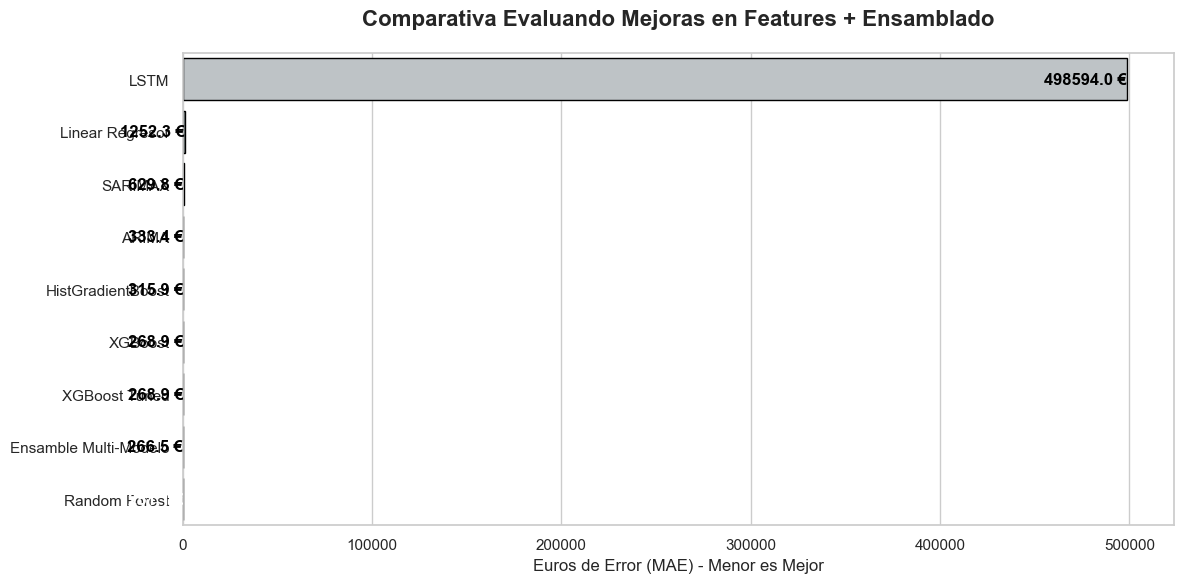

In [27]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

colores = ['#bdc3c7', '#95a5a6', '#7f8c8d', '#2ecc71']
grafico = sns.barplot(x='MAE', y='Modelo', data=df_results, palette=colores, edgecolor='black')

plt.title('Comparativa Evaluando Mejoras en Features + Ensamblado', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Euros de Error (MAE) - Menor es Mejor', fontsize=12)
plt.ylabel('')

for index, value in enumerate(df_results['MAE']):
    grafico.text(value - 5, index, f"{value:.1f} €", color='black' if index != len(df_results)-1 else 'white', 
                 ha="right", va="center", fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()